# Friends S1 — Translation Cost Savings Demo

This notebook translates the English subtitles from six *Friends* Season 1 episodes (E2–E7) to Czech, processing them sequentially so later episodes benefit from a growing translation cache.

It mirrors the architecture of Polydoc:
- Each subtitle line is embedded with `text-embedding-3-small` and queried against a local ChromaDB collection.
- **Cache hits** (cosine distance < 0.3) reuse stored translations — no GPT call needed.
- **Cache misses** are sent to `gpt-4o` in batches, then stored back for future reuse.

The result: reuse rates and cost savings grow with every episode.

In [1]:
import html, json, uuid
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import chromadb
import tiktoken
from openai import OpenAI
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()
client = OpenAI()

# ── Config ──────────────────────────────────────────────────────────────────
LANGUAGE_CODE = "cs"
LANGUAGE_FULL = "Czech"
BATCH_SIZE    = 30          # subtitle lines per GPT-4o call
CACHE_THRESH  = 0.3         # cosine distance threshold for a cache hit
EMB_MODEL     = "text-embedding-3-small"
GPT_MODEL     = "gpt-4o"

SUBTITLE_DIR = Path("documents/subtitles")

encoding = tiktoken.encoding_for_model("gpt-4o")

print(f"Config: lang={LANGUAGE_FULL} | batch_size={BATCH_SIZE} | threshold={CACHE_THRESH}")

Config: lang=Czech | batch_size=30 | threshold=0.3


In [2]:
# Single in-memory ChromaDB client shared across all episodes.
# The cache accumulates as episodes are processed in order.
chroma_client = chromadb.EphemeralClient()
collection = chroma_client.get_or_create_collection(
    name="translations",
    metadata={"hnsw:space": "cosine"},
)
print("ChromaDB EphemeralClient ready")

ChromaDB EphemeralClient ready


In [3]:
def load_subtitles(path: Path) -> list[str]:
    """Parse subtitle file → list of cleaned dialogue lines."""
    lines = []
    for raw in path.read_text(encoding="utf-8").splitlines():
        # Support both plain lines and tab-separated (index\ttext) formats
        parts = raw.split("\t", 1)
        text = html.unescape((parts[1] if len(parts) == 2 else parts[0]).strip())
        if text:
            lines.append(text)
    return lines

# Sanity check
ep_files = sorted(SUBTITLE_DIR.glob("*.txt"))
for f in ep_files:
    lines = load_subtitles(f)
    print(f"{f.name}: {len(lines)} lines")

s1e1.txt: 641 lines
s1e2.txt: 365 lines
s1e3.txt: 353 lines
s1e4.txt: 400 lines
s1e5.txt: 376 lines
s1e6.txt: 366 lines
s1e7.txt: 349 lines


In [4]:
class TranslatedTextSegments(BaseModel):
    text_segments: List[str]


def translate_subtitles(segments: list[str]):
    """Translate a batch of subtitle lines with GPT-4o structured output.

    Empty lines are skipped before sending to GPT-4o and reinserted afterwards.
    Returns (translated_list, usage).
    """
    non_empty_indices = [i for i, s in enumerate(segments) if s.strip()]
    non_empty = [segments[i] for i in non_empty_indices]

    if not non_empty:
        class _Usage:
            input_tokens = 0
            output_tokens = 0
        return [""] * len(segments), _Usage()

    system_prompt = f"""
You are a professional subtitle translator for TV shows.
You will be given an array of English dialogue lines from a sitcom.
Translate each line to natural {LANGUAGE_FULL}, preserving the meaning, tone, and humour.
Keep translations concise — the way a native {LANGUAGE_FULL} speaker would naturally say it.
Return an array with exactly the same number of elements in the same order.
    """

    user_prompt = f"""
Target language: {LANGUAGE_FULL}

Subtitle lines: {json.dumps(non_empty, ensure_ascii=False)}
    """

    res = client.responses.parse(
        model=GPT_MODEL,
        input=[
            {"role": "system", "content": system_prompt.strip()},
            {"role": "user",   "content": user_prompt.strip()},
        ],
        text_format=TranslatedTextSegments,
    )

    translated = res.output_parsed.text_segments

    result = [""] * len(segments)
    for idx, t in zip(non_empty_indices, translated):
        result[idx] = t
    return result, res.usage

In [5]:
def retrieve_and_cache(text_segments, language_code):
    """Query ChromaDB for existing translations.

    Returns: (translations_dict, to_translate, hits, saved_tokens)
    """
    translations = {}
    to_translate = []
    hits = 0
    saved_tokens = 0

    for ts in text_segments:
        if not ts.strip():
            to_translate.append(ts)
            continue

        query_emb = client.embeddings.create(
            model=EMB_MODEL, input=ts
        ).data[0].embedding

        results = collection.query(query_embeddings=[query_emb], n_results=1)

        if not results["distances"] or not results["distances"][0]:
            to_translate.append(ts)
            continue

        distance = results["distances"][0][0]

        if distance < CACHE_THRESH:
            metadata = results.get("metadatas", [[]])[0][0]
            if metadata and language_code in metadata:
                translations[ts] = metadata[language_code]
                hits += 1
                saved_tokens += len(encoding.encode(ts))
            else:
                to_translate.append(ts)
        else:
            to_translate.append(ts)

    return translations, to_translate, hits, saved_tokens


def store_translations(sources, translations):
    """Embed each source segment and store in ChromaDB."""
    for source, translation in zip(sources, translations):
        if not source.strip():
            continue
        unique_id = str(uuid.uuid4())
        emb = client.embeddings.create(
            model=EMB_MODEL, input=source
        ).data[0].embedding
        collection.add(
            ids=[unique_id],
            documents=[source],
            embeddings=[emb],
            metadatas=[{LANGUAGE_CODE: translation}],
        )

In [6]:
# Cost rates (USD per 1M tokens) — matches Polydoc backend constants
GPT4O_INPUT_RATE  = 2.50
GPT4O_OUTPUT_RATE = 10.00
EMB_RATE          = 0.02


def gpt_cost(input_tok, output_tok):
    return (input_tok / 1_000_000 * GPT4O_INPUT_RATE
            + output_tok / 1_000_000 * GPT4O_OUTPUT_RATE)


print(f"Rates — GPT-4o: ${GPT4O_INPUT_RATE}/1M input, ${GPT4O_OUTPUT_RATE}/1M output | "
      f"Embeddings: ${EMB_RATE}/1M")

Rates — GPT-4o: $2.5/1M input, $10.0/1M output | Embeddings: $0.02/1M


## Episode Translation

Episodes are processed in order (E2 → E7). The ChromaDB cache is empty at the start of E2, so it has 0% reuse. By E7, several hundred lines from earlier episodes are cached, and recurring phrases, filler lines, and repeated dialogue are served from the cache.

In [7]:
episode_results = []

# Reset the cache so reruns always start from a clean state
chroma_client.delete_collection("translations")
collection = chroma_client.get_or_create_collection(
    name="translations",
    metadata={"hnsw:space": "cosine"},
)
print("Cache cleared.")

for ep_file in sorted(SUBTITLE_DIR.glob("*.txt")):
    ep_label = ep_file.stem.upper().replace("S1", "S1 ")  # e.g. "S1 E2"
    lines = load_subtitles(ep_file)
    total_lines = len(lines)

    ep_hits    = 0
    all_misses = []  # all segments needing translation, collected across the full episode

    # Phase 1: cache lookup — scan all segments, collect misses (no translation yet)
    for batch_start in range(0, total_lines, BATCH_SIZE):
        batch = lines[batch_start : batch_start + BATCH_SIZE]
        _, to_translate, hits, _ = retrieve_and_cache(batch, LANGUAGE_CODE)
        ep_hits += hits
        all_misses.extend(to_translate)

    # Phase 2: translate all misses in batches
    ep_actual_input_tok  = 0
    ep_actual_output_tok = 0
    translated_misses    = []

    for batch_start in range(0, len(all_misses), BATCH_SIZE):
        batch = all_misses[batch_start : batch_start + BATCH_SIZE]
        if any(s.strip() for s in batch):
            new_translations, usage = translate_subtitles(batch)
            ep_actual_input_tok  += usage.input_tokens
            ep_actual_output_tok += usage.output_tokens
            translated_misses.extend(new_translations)
        else:
            translated_misses.extend([""] * len(batch))

    # Phase 3: store all new translations
    store_translations(all_misses, translated_misses)

    actual_cost = gpt_cost(ep_actual_input_tok, ep_actual_output_tok)

    # Theoretical cost: scale actual API usage to the full episode as if nothing
    # was cached. This uses the same token-counting method as actual_cost so
    # prompt overhead and JSON encoding are accounted for identically.
    ep_misses = total_lines - ep_hits
    if ep_misses > 0 and ep_actual_input_tok > 0:
        scale = total_lines / ep_misses
        theor_cost = gpt_cost(
            int(ep_actual_input_tok  * scale),
            int(ep_actual_output_tok * scale),
        )
    else:
        theor_cost = 0.0

    savings    = theor_cost - actual_cost
    reuse_rate = ep_hits / total_lines if total_lines > 0 else 0.0

    episode_results.append({
        "episode":          ep_label,
        "total_lines":      total_lines,
        "hits":             ep_hits,
        "misses":           ep_misses,
        "reuse_rate":       reuse_rate,
        "theoretical_cost": theor_cost,
        "actual_cost":      actual_cost,
        "savings":          savings,
    })

    print(
        f"[{ep_label}] lines={total_lines} "
        f"hits={ep_hits} ({reuse_rate:.1%}) "
        f"cost=${actual_cost:.5f} (theor ${theor_cost:.5f}) "
        f"saved=${savings:.5f}"
    )

print("\nDone.")

Cache cleared.
[S1 E1] lines=641 hits=0 (0.0%) cost=$0.07426 (theor $0.07426) saved=$0.00000
[S1 E2] lines=365 hits=32 (8.8%) cost=$0.05592 (theor $0.06129) saved=$0.00537
[S1 E3] lines=353 hits=34 (9.6%) cost=$0.05767 (theor $0.06381) saved=$0.00614
[S1 E4] lines=400 hits=54 (13.5%) cost=$0.06437 (theor $0.07441) saved=$0.01004
[S1 E5] lines=376 hits=56 (14.9%) cost=$0.05554 (theor $0.06524) saved=$0.00971
[S1 E6] lines=366 hits=32 (8.7%) cost=$0.05608 (theor $0.06144) saved=$0.00536
[S1 E7] lines=349 hits=75 (21.5%) cost=$0.04810 (theor $0.06125) saved=$0.01316

Done.


In [8]:
df = pd.DataFrame(episode_results)

display_df = df[[
    "episode", "total_lines", "hits", "misses", "reuse_rate",
    "theoretical_cost", "actual_cost", "savings",
]].copy()

display_df["reuse_rate"]       = display_df["reuse_rate"].map("{:.1%}".format)
display_df["theoretical_cost"] = display_df["theoretical_cost"].map("${:.5f}".format)
display_df["actual_cost"]      = display_df["actual_cost"].map("${:.5f}".format)
display_df["savings"]          = display_df["savings"].map("${:.5f}".format)
display_df.columns = [
    "Episode", "Lines", "Cache Hits", "Misses", "Reuse Rate",
    "Theoretical Cost", "Actual Cost", "Savings",
]
display_df.set_index("Episode", inplace=True)
display_df

,Lines,Cache Hits,Misses,Reuse Rate,Theoretical Cost,Actual Cost,Savings
Episode,,,,,,,
S1 E1,641,0,641,0.0%,$0.07426,$0.07426,$0.00000
S1 E2,365,32,333,8.8%,$0.06129,$0.05592,$0.00537
S1 E3,353,34,319,9.6%,$0.06381,$0.05767,$0.00614
S1 E4,400,54,346,13.5%,$0.07441,$0.06437,$0.01004
S1 E5,376,56,320,14.9%,$0.06524,$0.05554,$0.00971
S1 E6,366,32,334,8.7%,$0.06144,$0.05608,$0.00536
S1 E7,349,75,274,21.5%,$0.06125,$0.04810,$0.01316


## Analysis


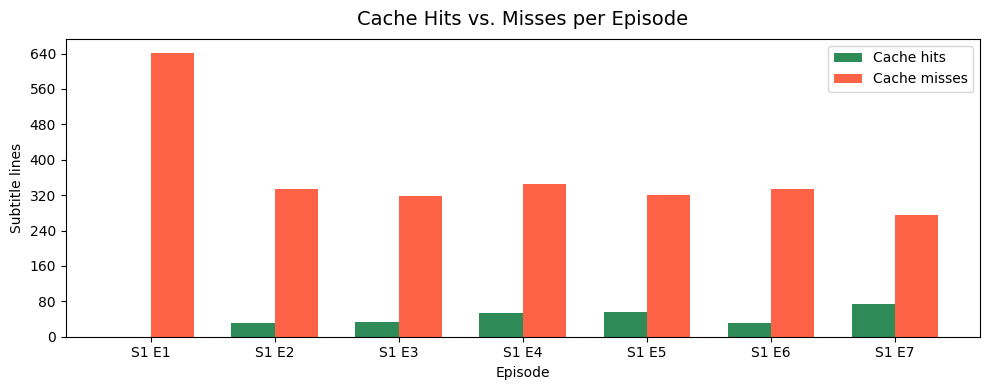

In [9]:
# Chart 1 — Cache hits vs. misses per episode
ep_labels  = [r["episode"] for r in episode_results]
hits_arr   = [r["hits"]   for r in episode_results]
misses_arr = [r["misses"] for r in episode_results]
x = np.arange(len(ep_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, hits_arr,   width, label="Cache hits",   color="seagreen")
ax.bar(x + width / 2, misses_arr, width, label="Cache misses", color="tomato")

ax.set_title("Cache Hits vs. Misses per Episode", fontsize=14, pad=10)
ax.set_xlabel("Episode")
ax.set_ylabel("Subtitle lines")
ax.set_xticks(x)
ax.set_xticklabels(ep_labels)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

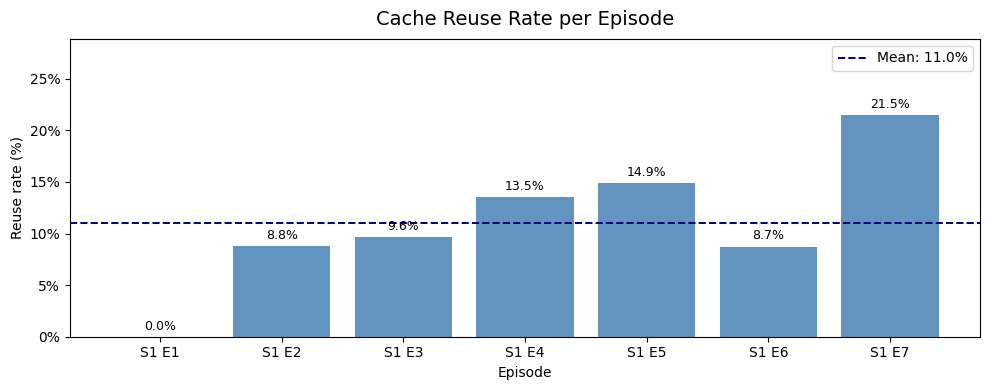

In [10]:
# Chart 2 — Reuse rate % per episode
reuse_pct = [r["reuse_rate"] * 100 for r in episode_results]
mean_reuse = np.mean(reuse_pct)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(ep_labels, reuse_pct, color="steelblue", alpha=0.85)
ax.axhline(mean_reuse, color="navy", linestyle="--", linewidth=1.4,
           label=f"Mean: {mean_reuse:.1f}%")

for bar, pct in zip(bars, reuse_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_title("Cache Reuse Rate per Episode", fontsize=14, pad=10)
ax.set_xlabel("Episode")
ax.set_ylabel("Reuse rate (%)")
ax.set_ylim(0, max(reuse_pct) * 1.25 + 2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
plt.tight_layout()
plt.show()

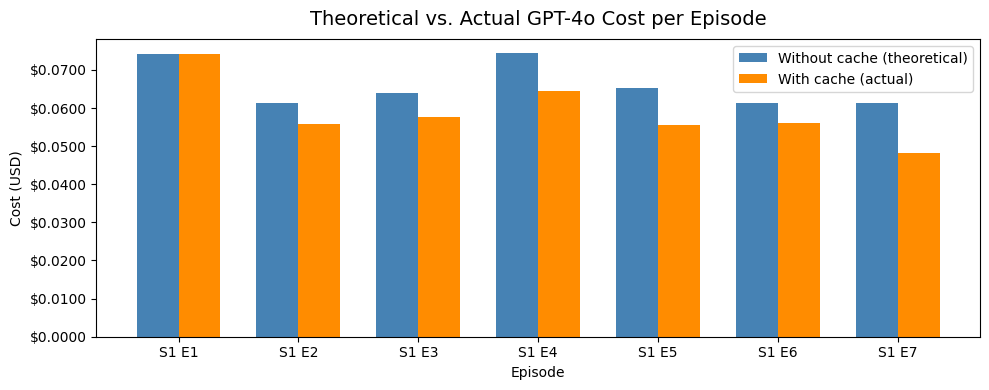

In [11]:
# Chart 3 — Theoretical vs. actual GPT-4o cost per episode
theor_arr  = [r["theoretical_cost"] for r in episode_results]
actual_arr = [r["actual_cost"]       for r in episode_results]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, theor_arr,  width, label="Without cache (theoretical)", color="steelblue")
ax.bar(x + width / 2, actual_arr, width, label="With cache (actual)",         color="darkorange")

ax.set_title("Theoretical vs. Actual GPT-4o Cost per Episode", fontsize=14, pad=10)
ax.set_xlabel("Episode")
ax.set_ylabel("Cost (USD)")
ax.set_xticks(x)
ax.set_xticklabels(ep_labels)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.4f"))
ax.legend()
plt.tight_layout()
plt.show()

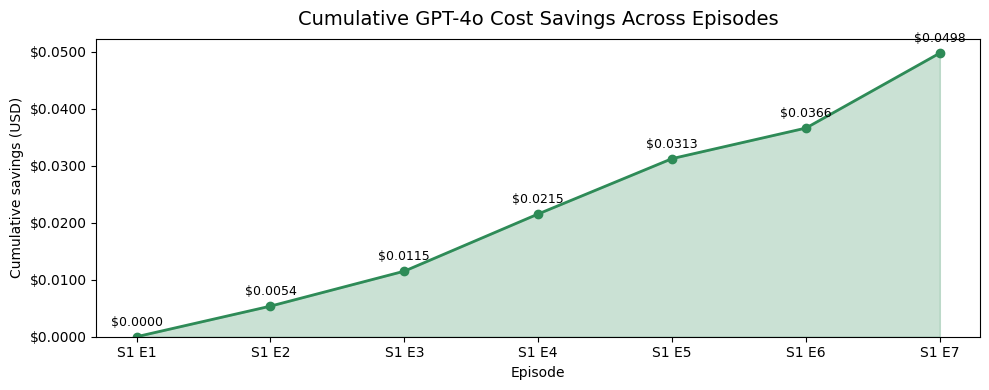

In [12]:
# Chart 4 — Cumulative cost savings across episodes
savings_arr = [r["savings"] for r in episode_results]
cum_savings = np.cumsum(savings_arr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(ep_labels, cum_savings, alpha=0.25, color="seagreen")
ax.plot(ep_labels, cum_savings, marker="o", color="seagreen", linewidth=2)

for i, (ep, val) in enumerate(zip(ep_labels, cum_savings)):
    ax.annotate(f"${val:.4f}", (ep, val),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)

ax.set_title("Cumulative GPT-4o Cost Savings Across Episodes", fontsize=14, pad=10)
ax.set_xlabel("Episode")
ax.set_ylabel("Cumulative savings (USD)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.4f"))
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [13]:
# Summary
total_lines  = sum(r["total_lines"]       for r in episode_results)
total_hits   = sum(r["hits"]               for r in episode_results)
total_theor  = sum(r["theoretical_cost"]   for r in episode_results)
total_actual = sum(r["actual_cost"]        for r in episode_results)
total_saved  = sum(r["savings"]            for r in episode_results)
overall_reuse = total_hits / total_lines
saving_pct   = total_saved / total_theor * 100 if total_theor > 0 else 0

print("=" * 48)
print("OVERALL SUMMARY (S1 E2–E7)")
print("=" * 48)
print(f"Total subtitle lines translated : {total_lines:,}")
print(f"Total cache hits                : {total_hits:,} ({overall_reuse:.1%})")
print(f"Theoretical cost (no cache)     : ${total_theor:.5f}")
print(f"Actual cost (with cache)        : ${total_actual:.5f}")
print(f"Total savings                   : ${total_saved:.5f} ({saving_pct:.1f}% reduction)")
print("=" * 48)

OVERALL SUMMARY (S1 E2–E7)
Total subtitle lines translated : 2,850
Total cache hits                : 283 (9.9%)
Theoretical cost (no cache)     : $0.46171
Actual cost (with cache)        : $0.41194
Total savings                   : $0.04977 (10.8% reduction)
